# Entrega 3

**Equipo:** Sofia Bojreibe y Facundo Rodriguez

## Prediccion de Abandono de Clientes Bancarios

El abandono de clientes (*churn*) es un desafio importante en el sector bancario. Identificar a los clientes propensos a cerrar sus cuentas permite implementar estrategias proactivas de retencion.

**Objetivo:** predecir la probabilidad de que un cliente abandone el banco (`Exited`), evaluado con **AUC-ROC**.




## 1. Setup

In [ ]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, average_precision_score

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
PALETA = ['#19326E', '#CD742A', '#50ACB0', '#A3477F', '#907FAB', '#4294CC', '#89A943']
RANDOM_STATE = 42

## 2. Carga De Datos



In [ ]:
# Subir train.csv, test.csv y sample_submission.csv
# a la carpeta del notebook o a una carpeta data/.

rutas_posibles = [Path('data'), Path('.')]

def cargar(nombre):
    for carpeta in rutas_posibles:
        ruta = carpeta / nombre
        if ruta.exists():
            return pd.read_csv(ruta)
    raise FileNotFoundError(f'No se encontro {nombre}. Subilo a la carpeta del notebook o a data/.')

train = cargar('train.csv')
test = cargar('test.csv')
sample_submission = cargar('submission.csv')

print(f'Dimensiones train: {train.shape}')
print(f'Dimensiones test: {test.shape}')

Dimensiones train: (15000, 14)
Dimensiones test: (10000, 13)


## 3. Auditoria General De Los Datos

In [ ]:
audit = pd.DataFrame({
    'dtype':          train.dtypes,
    'nulos':          train.isnull().sum(),
    'pct_nulos':      (train.isnull().sum() / len(train) * 100).round(2),
    'valores_únicos': train.nunique(),
})
print('\n--- Auditoria de train ---')
print(audit)

print('\nBalance de clases (Exited):')
print(train['Exited'].value_counts(normalize=True))

# Tasa de churn por variable categorica / discreta
for col in ['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']:
    print(f'\n--- Tasa de churn por {col} ---')
    print(train.groupby(col)['Exited'].agg(['mean', 'count']))


--- Auditoria de train ---
                   dtype  nulos  pct_nulos  valores_únicos
id                 int64      0        0.0           15000
CustomerId       float64      0        0.0            6309
Surname           object      0        0.0             763
CreditScore      float64      0        0.0             378
Geography         object      0        0.0               3
Gender            object      0        0.0               2
Age              float64      0        0.0              55
Tenure           float64      0        0.0              11
Balance          float64      0        0.0            3328
NumOfProducts    float64      0        0.0               4
HasCrCard        float64      0        0.0               2
IsActiveMember   float64      0        0.0               2
EstimatedSalary  float64      0        0.0            6270
Exited           float64      0        0.0               2

Balance de clases (Exited):
Exited
0.0    0.7996
1.0    0.2004
Name: proportion, dtype

## 4. Feature Engineering



In [ ]:
def crear_features(df):
    """Genera variables derivadas. Todas row-wise: cada fila usa solo sus propios
    valores, por lo tanto no hay riesgo de fuga de informacion entre filas."""
    df = df.copy()

    # Indicadores financieros relativos al Balance
    df['BalancePerProduct'] = df['Balance'] / df['NumOfProducts']
    df['BalancePerTenure'] = df['Balance'] / (df['Tenure'] + 1)
    df['SalaryToBalanceRatio'] = df['EstimatedSalary'] / (df['Balance'] + 1)
    df['HasBalance'] = (df['Balance'] > 0).astype(int)

    # Interacciones
    df['Balance_x_IsActiveMember'] = df['Balance'] * df['IsActiveMember']
    df['Tenure_x_HasCrCard'] = df['Tenure'] * df['HasCrCard']
    df['Age_x_CreditScore'] = df['Age'] * df['CreditScore']

    # Score sintetico de lealtad con pesos asignados
    df['LoyaltyIndex'] = (
        0.5 * (df['Tenure'] / 10) + 0.3 * df['IsActiveMember'] + 0.2 * (df['NumOfProducts'] / 4)
    )

    # Binning / categorizacion | Convertimos variables numericas en categorias para que el modelo pueda tratar
    # ciertos rangos como "un mismo grupo", ademas de tener el valor numerico crudo.

    df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 30, 40, 50, 100],
                            labels=['<30', '30-40', '40-50', '50+'])
    df['CreditScoreCategory'] = pd.cut(df['CreditScore'], bins=[0, 580, 670, 740, 850],
                                       labels=['Poor', 'Average', 'Good', 'Excellent'])

    # NumOfProducts no tiene relacion lineal con el churn (en el EDA vimos que 3-4
    # productos implica churn casi seguro), por eso ademas de numerico lo tratamos
    # como categoria.
    df['NumOfProductsCat'] = df['NumOfProducts'].astype(int).astype(str)


    # Combinaciones de las variables que el EDA mostro como mas fuertes.
    df['Age_x_IsActive'] = df['Age'] * df['IsActiveMember']
    df['EsAleman_x_NoActivo'] = ((df['Geography'] == 'Germany') &
                                 (df['IsActiveMember'] == 0)).astype(int)
    df['ProductosRiesgo'] = (df['NumOfProducts'] >= 3).astype(int)
    df['SaldoCero_x_Productos'] = (df['Balance'] == 0).astype(int) * df['NumOfProducts']

    return df


class FrecuenciaApellido(BaseEstimator, TransformerMixin):
    """Frequency encoding de Surname, calculado solo con los datos de entrenamiento
    de cada fold. Es la misma idea de value_counts(), pero envuelta en un
    transformer para que sklearn respete la separacion train/validacion."""

    def fit(self, X, y=None):
        self.mapa_ = X['Surname'].value_counts()
        return self

    def transform(self, X):
        X = X.copy()
        X['SurnameFreq'] = X['Surname'].map(self.mapa_).fillna(0)
        return X.drop(columns=['Surname'])


# Aplicamos el feature engineering row-wise. Surname se conserva por ahora:
# lo consume y elimina el transformer de arriba, ya dentro del pipeline.
train_fe = crear_features(train)
test_fe = crear_features(test)

columnas_drop = ['id', 'CustomerId']
if 'RowNumber' in train_fe.columns:
    columnas_drop.append('RowNumber')

X_train_full = train_fe.drop(columns=[c for c in columnas_drop if c in train_fe.columns] + ['Exited'])
y_train_full = train_fe['Exited']
X_test_kaggle = test_fe.drop(columns=[c for c in columnas_drop if c in test_fe.columns])

print(f'\nShape de features de train: {X_train_full.shape}')
print('Columnas:', list(X_train_full.columns))


Shape de features de train: (15000, 26)
Columnas: ['Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'BalancePerProduct', 'BalancePerTenure', 'SalaryToBalanceRatio', 'HasBalance', 'Balance_x_IsActiveMember', 'Tenure_x_HasCrCard', 'Age_x_CreditScore', 'LoyaltyIndex', 'AgeGroup', 'CreditScoreCategory', 'NumOfProductsCat', 'Age_x_IsActive', 'EsAleman_x_NoActivo', 'ProductosRiesgo', 'SaldoCero_x_Productos']


## 5. Chequeo De Nulos En Test

En esta competencia `test.csv` trae 1 fila con `HasCrCard` nulo que no existia en `train.csv`. Por eso el pipeline lleva `SimpleImputer`.

In [ ]:
# En esta competencia test.csv trae 1 fila con HasCrCard nulo que no existia en
# train.csv. Por eso el pipeline lleva SimpleImputer: no asumimos que los datos
# siempre vienen completos.
print('\nNulos en train:')
print(X_train_full.isnull().sum()[X_train_full.isnull().sum() > 0])
print('\nNulos en test:')
print(X_test_kaggle.isnull().sum()[X_test_kaggle.isnull().sum() > 0])


Nulos en train:
Series([], dtype: int64)

Nulos en test:
HasCrCard             1
Tenure_x_HasCrCard    1
dtype: int64


## 6. Preprocesamiento

In [ ]:
# Las columnas se determinan después de que FrecuenciaApellido saque Surname y
# agregue SurnameFreq, asi que las calculamos sobre una transformacion de prueba.
_muestra = FrecuenciaApellido().fit(X_train_full).transform(X_train_full)
num_cols = _muestra.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = _muestra.select_dtypes(exclude=[np.number]).columns.tolist()

print('\nNumericas:', num_cols)
print('Categoricas:', cat_cols)

pipe_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
pipe_cat = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])
preprocesador = ColumnTransformer([
    ('num', pipe_num, num_cols),
    ('cat', pipe_cat, cat_cols),
])

def armar_pipeline(modelo):
    """Pipeline completo: frequency encoding -> preprocesamiento -> modelo.
    Todo lo que aprende de los datos queda adentro, asi la validacion cruzada
    es honesta."""
    return Pipeline([
        ('freq', FrecuenciaApellido()),
        ('prep', preprocesador),
        ('modelo', modelo),
    ])


Numericas: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'BalancePerProduct', 'BalancePerTenure', 'SalaryToBalanceRatio', 'HasBalance', 'Balance_x_IsActiveMember', 'Tenure_x_HasCrCard', 'Age_x_CreditScore', 'LoyaltyIndex', 'Age_x_IsActive', 'EsAleman_x_NoActivo', 'ProductosRiesgo', 'SaldoCero_x_Productos', 'SurnameFreq']
Categoricas: ['Geography', 'Gender', 'AgeGroup', 'CreditScoreCategory', 'NumOfProductsCat']


## 7. Comparacion De Modelos



In [ ]:
modelos = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'DecisionTree': DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'KNN': KNeighborsClassifier(n_neighbors=15),
    'SVM': SVC(probability=True, random_state=RANDOM_STATE),
    'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

resultados = []
print('\n--- Comparacion de modelos (5-fold CV) ---')
for nombre, modelo in modelos.items():
    pipe = armar_pipeline(modelo)
    scores = cross_val_score(pipe, X_train_full, y_train_full,
                             cv=skf, scoring='roc_auc', n_jobs=-1)
    resultados.append({
        'modelo': nombre,
        'auc_cv_mean': scores.mean(),
        'auc_cv_std': scores.std(),
    })
    print(f'{nombre:22s} | AUC: {scores.mean():.4f} (+/-{scores.std():.4f})')

tabla_resultados = pd.DataFrame(resultados).sort_values('auc_cv_mean', ascending=False)
print('\n', tabla_resultados)


--- Comparacion de modelos (5-fold CV) ---
LogisticRegression     | AUC: 0.9272 (+/-0.0039)
DecisionTree           | AUC: 0.9105 (+/-0.0072)
RandomForest           | AUC: 0.9226 (+/-0.0057)
KNN                    | AUC: 0.9080 (+/-0.0044)
SVM                    | AUC: 0.8983 (+/-0.0098)
GradientBoosting       | AUC: 0.9319 (+/-0.0051)
HistGradientBoosting   | AUC: 0.9284 (+/-0.0044)

                  modelo  auc_cv_mean  auc_cv_std
5      GradientBoosting     0.931899    0.005130
6  HistGradientBoosting     0.928380    0.004439
0    LogisticRegression     0.927247    0.003866
2          RandomForest     0.922628    0.005708
1          DecisionTree     0.910454    0.007168
3                   KNN     0.907967    0.004398
4                   SVM     0.898344    0.009837


## 8. Ajuste De Hiperparametros



In [ ]:
# NOTA: el grid tiene 72 combinaciones x 5 folds. En Colab puede tardar
# ~15-30 minutos.

pipe_gb = armar_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE))

param_grid = {
    'modelo__n_estimators':     [300, 500],
    'modelo__learning_rate':    [0.03, 0.05],
    'modelo__max_depth':        [3, 4],
    'modelo__subsample':        [0.8, 1.0],
    'modelo__min_samples_leaf': [1, 20],
}

grid = GridSearchCV(pipe_gb, param_grid, scoring='roc_auc',
                    cv=skf, n_jobs=-1, verbose=1)
grid.fit(X_train_full, y_train_full)

print('\nMejores parametros:', grid.best_params_)
print('Mejor AUC (CV):', round(grid.best_score_, 4))

Fitting 5 folds for each of 32 candidates, totalling 160 fits

Mejores parametros: {'modelo__learning_rate': 0.05, 'modelo__max_depth': 3, 'modelo__min_samples_leaf': 20, 'modelo__n_estimators': 300, 'modelo__subsample': 0.8}
Mejor AUC (CV): 0.9327


## 9. Validacion Final Del Modelo Elegido



In [ ]:
modelo_final_params = {k.replace('modelo__', ''): v for k, v in grid.best_params_.items()}
modelo_final = GradientBoostingClassifier(random_state=RANDOM_STATE, **modelo_final_params)

skf10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

pipe_final = armar_pipeline(modelo_final)
scores_final = cross_val_score(pipe_final, X_train_full, y_train_full,
                               cv=skf10, scoring='roc_auc', n_jobs=-1)

print(f'\n--- Validacion final (10 folds reales) ---')
print(f'AUC medio: {scores_final.mean():.4f}')
print(f'Desvio:    {scores_final.std():.4f}')
print(f'Rango aproximado esperado: {scores_final.mean() - 2*scores_final.std():.4f} '
      f'a {scores_final.mean() + 2*scores_final.std():.4f}')

# Comparacion contra el GradientBoosting por default, para saber si el
# tuning aporto algo real o esta dentro del ruido.
pipe_default = armar_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE))
scores_default = cross_val_score(pipe_default, X_train_full, y_train_full,
                                 cv=skf10, scoring='roc_auc', n_jobs=-1)

diferencia = scores_final.mean() - scores_default.mean()
print(f'\nGB tuneado:  {scores_final.mean():.4f} (+/-{scores_final.std():.4f})')
print(f'GB default:  {scores_default.mean():.4f} (+/-{scores_default.std():.4f})')
print(f'Diferencia:  {diferencia:+.4f}')

if abs(diferencia) < scores_final.std():
    print('LECTURA: la diferencia es menor al desvio entre folds. Es ruido, no mejora real.')
else:
    print('LECTURA: la diferencia supera el desvio entre folds. Hay mejora sostenida.')


--- Validacion final (10 folds reales) ---
AUC medio: 0.9326
Desvio:    0.0054
Rango aproximado esperado: 0.9218 a 0.9435

GB tuneado:  0.9326 (+/-0.0054)
GB default:  0.9325 (+/-0.0055)
Diferencia:  +0.0002
LECTURA: la diferencia es menor al desvio entre folds. Es ruido, no mejora real.


## 10. Curva Roc Vs Precision-Recall

Para este grafico si necesitamos un holdout (hay que predecir sobre datos que el modelo no vio). Se usa **solo para graficar**, no para elegir el modelo — esa decision ya se tomo con la CV de la seccion anterior.

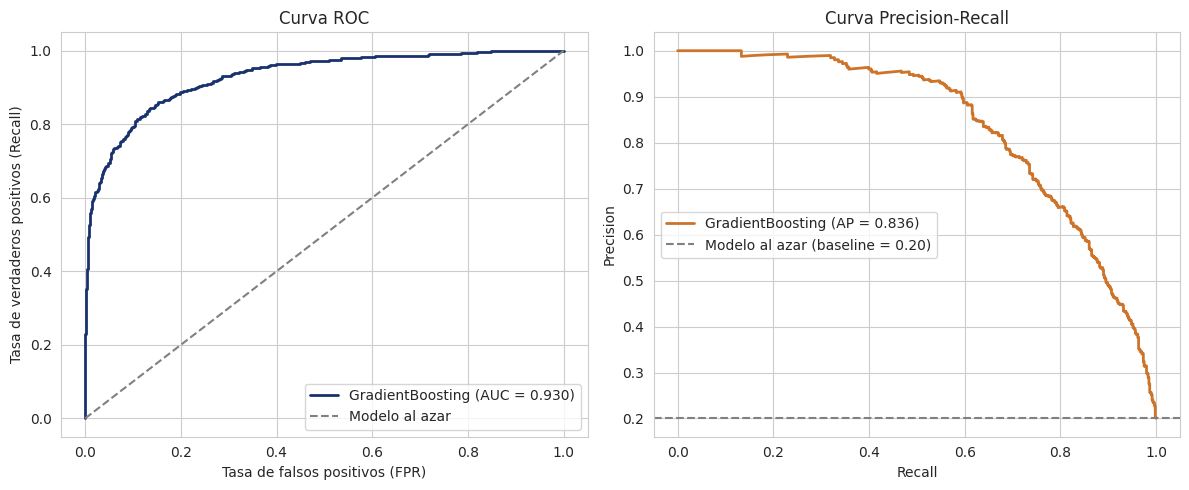


AUC-ROC (holdout):            0.9296
Average Precision / PR-AUC:   0.8356
Tasa base de churn (holdout): 0.2003


In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2,
    stratify=y_train_full, random_state=RANDOM_STATE
)

pipe_grafico = armar_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE, **modelo_final_params))
pipe_grafico.fit(X_tr, y_tr)
y_prob_val = pipe_grafico.predict_proba(X_val)[:, 1]

fpr, tpr, _ = roc_curve(y_val, y_prob_val)
auc_holdout = roc_auc_score(y_val, y_prob_val)

precision, recall, _ = precision_recall_curve(y_val, y_prob_val)
ap = average_precision_score(y_val, y_prob_val)
tasa_base = y_val.mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, color=PALETA[0], linewidth=2, label=f'GradientBoosting (AUC = {auc_holdout:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Modelo al azar')
axes[0].set_xlabel('Tasa de falsos positivos (FPR)')
axes[0].set_ylabel('Tasa de verdaderos positivos (Recall)')
axes[0].set_title('Curva ROC')
axes[0].legend()

axes[1].plot(recall, precision, color=PALETA[1], linewidth=2, label=f'GradientBoosting (AP = {ap:.3f})')
axes[1].axhline(tasa_base, color='gray', linestyle='--', label=f'Modelo al azar (baseline = {tasa_base:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nAUC-ROC (holdout):            {auc_holdout:.4f}')
print(f'Average Precision / PR-AUC:   {ap:.4f}')
print(f'Tasa base de churn (holdout): {tasa_base:.4f}')

## 11. Modelo Final Y Submission

In [ ]:
pipe_submission = armar_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE, **modelo_final_params))
pipe_submission.fit(X_train_full, y_train_full)

pred_proba = pipe_submission.predict_proba(X_test_kaggle)[:, 1]

submission = pd.DataFrame({'id': test['id'], 'Exited': pred_proba})
submission.to_csv('submission.csv', index=False)

print('\nsubmission.csv generado:', submission.shape)
print(submission.head())


submission.csv generado: (10000, 2)
      id    Exited
0  15000  0.012554
1  15001  0.538899
2  15002  0.015470
3  15003  0.972581
4  15004  0.099413


## 12. Verificacion De Formato Y Sensatez




Verificacion de formato: OK, coincide con sample_submission.csv

--- Chequeo de sensatez ---
count    10000.000000
mean         0.201724
std          0.295865
min          0.004503
25%          0.016511
50%          0.044016
75%          0.235956
max          0.996062
Name: Exited, dtype: float64

Prediccion promedio (test): 0.2017
Tasa real de churn (train): 0.2004


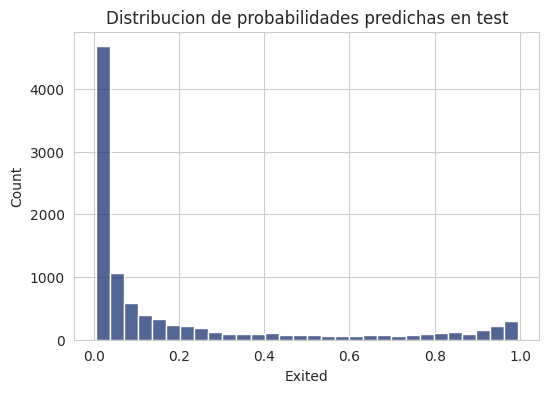

In [ ]:

assert list(submission.columns) == list(sample_submission.columns), 'Columnas no coinciden'
assert len(submission) == len(sample_submission), 'Cantidad de filas no coincide'
assert (submission['id'].values == sample_submission['id'].values).all(), 'ids no coinciden o no estan en el mismo orden'
assert submission['Exited'].between(0, 1).all(), 'Hay probabilidades fuera de [0,1]'
assert submission['Exited'].isnull().sum() == 0, 'Hay valores nulos en Exited'

print('\nVerificacion de formato: OK, coincide con sample_submission.csv')

print('\n--- Chequeo de sensatez ---')
print(submission['Exited'].describe())
print(f"\nPrediccion promedio (test): {submission['Exited'].mean():.4f}")
print(f'Tasa real de churn (train): {y_train_full.mean():.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(submission['Exited'], bins=30, color=PALETA[0], ax=ax)
ax.set_title('Distribucion de probabilidades predichas en test')
plt.show()

## 13. Interpretacion: Variables Mas Importantes

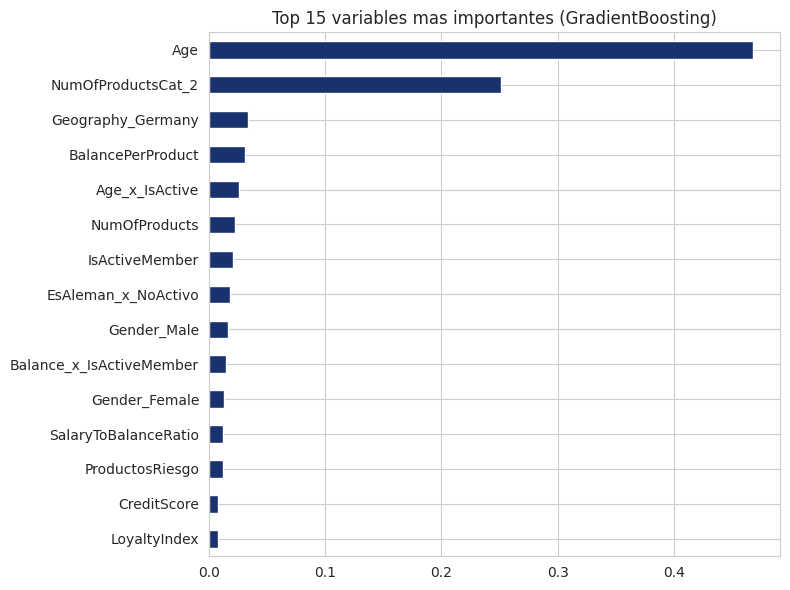


--- Top 15 variables ---
Age                         0.467708
NumOfProductsCat_2          0.250840
Geography_Germany           0.033472
BalancePerProduct           0.031406
Age_x_IsActive              0.025506
NumOfProducts               0.022497
IsActiveMember              0.021093
EsAleman_x_NoActivo         0.018347
Gender_Male                 0.016467
Balance_x_IsActiveMember    0.014409
Gender_Female               0.013287
SalaryToBalanceRatio        0.012553
ProductosRiesgo             0.011817
CreditScore                 0.008041
LoyaltyIndex                0.008036
dtype: float64


In [ ]:
nombres_ohe = (pipe_submission.named_steps['prep']
               .named_transformers_['cat']
               .named_steps['onehot']
               .get_feature_names_out(cat_cols))
nombres_features = num_cols + list(nombres_ohe)

importancias = pd.Series(
    pipe_submission.named_steps['modelo'].feature_importances_,
    index=nombres_features
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importancias.head(15).sort_values().plot(kind='barh', color=PALETA[0], ax=ax)
ax.set_title('Top 15 variables mas importantes (GradientBoosting)')
plt.tight_layout()
plt.show()

print('\n--- Top 15 variables ---')
print(importancias.head(15))

## 14. Descarga

In [ ]:
 from google.colab import files
 files.download('submission.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>